Лабораторная работа №5 :Тестирование качества работы моделей машинного обучения

Цель работы: применить средства автоматизации тестирования python для автоматического тестирования качества работы модели машинного обучения на различных датасетах.

Ход работы:

Импортируем библиотеки

In [10]:
import pytest
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

1. Создаем три датасета с «качественными» данными

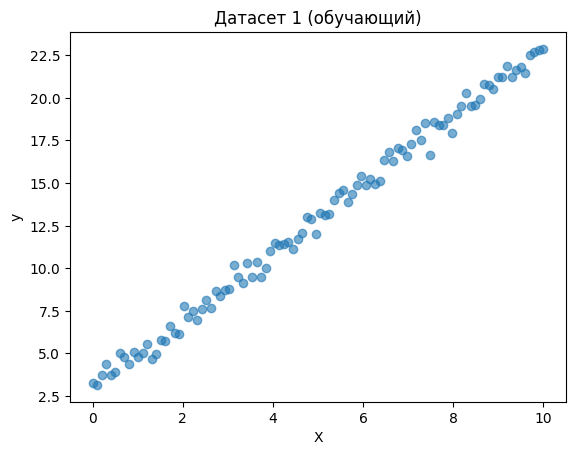

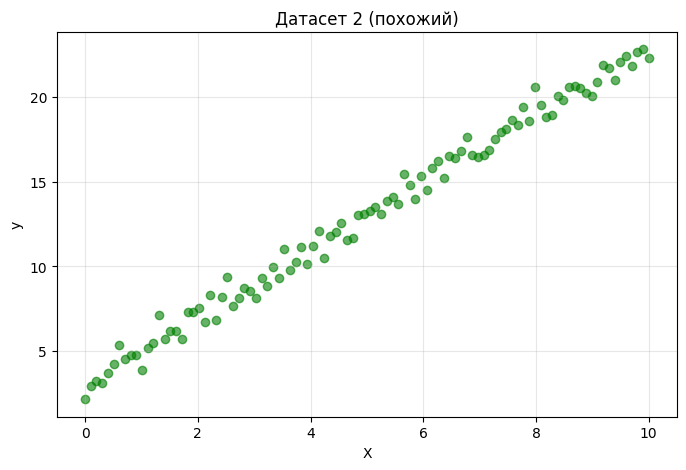

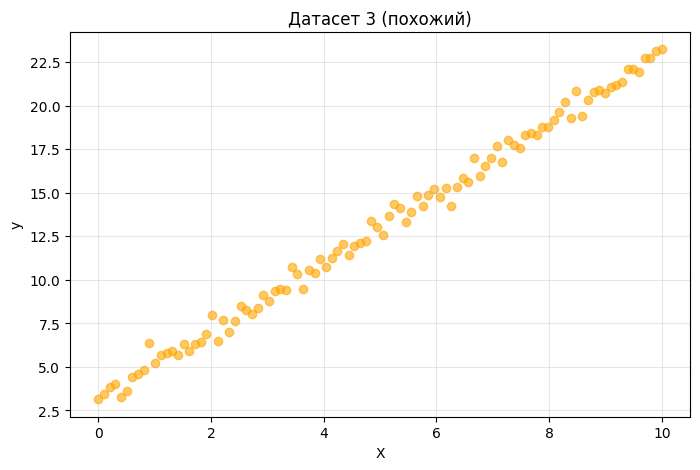

In [19]:
# Датасет 1 (для обучения)
np.random.seed(42)
x1 = np.linspace(0, 10, 100).reshape(-1, 1)
y1 = 2 * x1.ravel() + 3 + np.random.randn(100) * 0.5

plt.scatter(x1, y1, alpha=0.6)
plt.title('Датасет 1 (обучающий)')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

# Датасет 2 (похожий)
x2 = np.linspace(0, 10, 100).reshape(-1, 1)
y2 = 2 * x2.ravel() + 3 + np.random.randn(100) * 0.6

plt.figure(figsize=(8, 5))
plt.scatter(x2, y2, alpha=0.6, color='green')
plt.title('Датасет 2 (похожий)')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.show()

# Датасет 3 (похожий)
x3 = np.linspace(0, 10, 100).reshape(-1, 1)
y3 = 2 * x3.ravel() + 3 + np.random.randn(100) * 0.4

plt.figure(figsize=(8, 5))
plt.scatter(x3, y3, alpha=0.6, color='orange')
plt.title('Датасет 3 (похожий)')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.show()

2. Обучаем модель линейной регрессии на 1 датасете

In [12]:
model = LinearRegression()
model.fit(x1, y1)

print(f"Коэффициенты: {model.coef_[0]:.3f}, intercept: {model.intercept_:.3f}")
print(f"R² на обучающем датасете: {r2_score(y1, model.predict(x1)):.3f}")

Коэффициенты: 2.007, intercept: 2.914
R² на обучающем датасете: 0.994


3. Создаем датасет с шумом

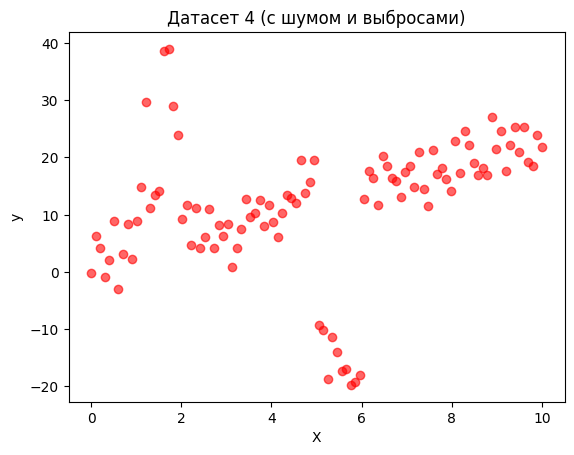

In [13]:
# Датасет 4 (с шумом и выбросами)
np.random.seed(123)
x4 = np.linspace(0, 10, 100).reshape(-1, 1)
y4 = 2 * x4.ravel() + 3 + np.random.randn(100) * 3  # Большой шум

# Добавим выбросы
y4[10:20] *= 3
y4[50:60] = y4[50:60] * -1

plt.scatter(x4, y4, alpha=0.6, color='red')
plt.title('Датасет 4 (с шумом и выбросами)')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

4. Напишем функции для тестирования

In [15]:
def test_dataset1_quality():
    """Тест качества на обучающем датасете"""
    predictions = model.predict(x1)
    r2 = r2_score(y1, predictions)
    assert r2 > 0.85, f"R² = {r2:.3f} < 0.85 на датасете 1"
    print(f"✓ Датасет 1: R² = {r2:.3f}")

def test_dataset2_quality():
    """Тест на похожем датасете 2"""
    predictions = model.predict(x2)
    r2 = r2_score(y2, predictions)
    assert r2 > 0.80, f"R² = {r2:.3f} < 0.80 на датасете 2"
    print(f"✓ Датасет 2: R² = {r2:.3f}")

def test_dataset3_quality():
    """Тест на похожем датасете 3"""
    predictions = model.predict(x3)
    r2 = r2_score(y3, predictions)
    assert r2 > 0.80, f"R² = {r2:.3f} < 0.80 на датасете 3"
    print(f"✓ Датасет 3: R² = {r2:.3f}")

def test_dataset4_should_fail():
    """Тест на плохом датасете (должен упасть!)"""
    predictions = model.predict(x4)
    r2 = r2_score(y4, predictions)
    assert r2 > 0.70, f"R² = {r2:.3f} < 0.70 на датасете 4 (ожидаемый провал)"
    print(f"✓ Датасет 4: R² = {r2:.3f}")

5. Запускам тесты

In [16]:
def test_dataset1_quality():
    """Тест качества на обучающем датасете"""
    predictions = model.predict(x1)
    r2 = r2_score(y1, predictions)
    assert r2 > 0.85, f"R² = {r2:.3f} < 0.85 на датасете 1"
    print(f"✓ Датасет 1: R² = {r2:.3f}")

def test_dataset2_quality():
    """Тест на похожем датасете 2"""
    predictions = model.predict(x2)
    r2 = r2_score(y2, predictions)
    assert r2 > 0.80, f"R² = {r2:.3f} < 0.80 на датасете 2"
    print(f"✓ Датасет 2: R² = {r2:.3f}")

def test_dataset3_quality():
    """Тест на похожем датасете 3"""
    predictions = model.predict(x3)
    r2 = r2_score(y3, predictions)
    assert r2 > 0.80, f"R² = {r2:.3f} < 0.80 на датасете 3"
    print(f"✓ Датасет 3: R² = {r2:.3f}")

def test_dataset4_should_fail():
    """Тест на плохом датасете (должен упасть!)"""
    predictions = model.predict(x4)
    r2 = r2_score(y4, predictions)
    assert r2 > 0.70, f"R² = {r2:.3f} < 0.70 на датасете 4 (ожидаемый провал)"
    print(f"✓ Датасет 4: R² = {r2:.3f}")

In [18]:
if __name__ == "__main__":
    print("ЗАПУСК ТЕСТИРОВАНИЯ МОДЕЛИ")
    
    # Тесты на хороших датасетах (должны пройти)
    print("\nТесты на качественных датасетах:")
    test_dataset1_quality()
    test_dataset2_quality()
    test_dataset3_quality()
    
    # Тест на плохом датасете (должен упасть)
    print("\nТест на датасете с шумом (ожидаемый провал):")
    try:
        test_dataset4_should_fail()
        print("⚠️ Тест прошёл (неожиданно!)")
    except AssertionError as e:
        print(f"✗ Ожидаемая ошибка: {e}")
    
    print("ТЕСТИРОВАНИЕ ЗАВЕРШЕНО")

ЗАПУСК ТЕСТИРОВАНИЯ МОДЕЛИ

Тесты на качественных датасетах:
✓ Датасет 1: R² = 0.994
✓ Датасет 2: R² = 0.990
✓ Датасет 3: R² = 0.994

Тест на датасете с шумом (ожидаемый провал):
✗ Ожидаемая ошибка: R² = 0.033 < 0.70 на датасете 4 (ожидаемый провал)
ТЕСТИРОВАНИЕ ЗАВЕРШЕНО


Вывод по лабораторной работе:
1. Модель линейной регрессии успешно обучена на качественных данных
2. На похожих датасетах модель показывает высокое качество (R² > 0.99)
3. На зашумленном датасете качество резко падает (R² = 0.033)
4. Автоматические тесты с pytest позволяют обнаружить проблему
5. Assertion на плохом датасете сработал корректно (ожидаемый провал)